In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.models import Model
from keras.layers import Input, Dense
from keras.optimizers import Adam
from skimage.metrics import structural_similarity as ssim #değerlendirme için 

2025-08-22 17:16:48.619083: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


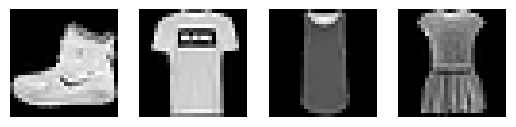

In [2]:
(x_train,_), (x_test,_) = fashion_mnist.load_data() 

#data normalization
x_train = x_train.astype("float32")/255.0
x_test = x_test.astype("float32")/255.0

#görselleştirme
plt.figure()
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(x_train[i],cmap="gray")
    plt.axis("off")
plt.show()

#veriyi düzleştir 28x28 boyutundaki görüntüleri 784 boyutunda bir vektöre çevir
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))

In [3]:
#autoencoder için model parametrelerini tanımlama
input_dim = x_train.shape[1] #giriş boyutu (784)
encoding_dim = 64 #latent boyutu 

#encoder kısmının inşa edilmesi
input_image = Input(shape= (input_dim, )) #girdi boyutunu belirliyoruz (784)
encoded = Dense(512, activation="relu")(input_image) #ilk gizli katman (512 noron)
encoded = Dense(256, activation="relu")(input_image) #ikinci gizli katman (256 noron)
encoded = Dense(128, activation="relu")(encoded) # üçüncü gizli katman
encoded = Dense(encoding_dim, activation="relu")(encoded) #sıkıştırma katmanı (64 boyut)

#decoder kısmının inşa edilmesi
decoded = Dense(128, activation="relu")(encoded) #ilk genişletme katmanı
decoded = Dense(256, activation="relu")(decoded) #ikinci genişletme katmanı
decoded = Dense(512, activation="relu")(decoded) #üçüncü genişletme katman
decoded = Dense(input_dim, activation="sigmoid")(decoded) #çıktı katmanı (784)

#autoencoders oluşturma = encoder + decoder
autoencoder = Model(input_image, decoded) #gişiten çıktıya tüm yapıyı tanımlıyoruz 

2025-08-22 17:16:51.710707: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
#modelin compile edilmesi
autoencoder.compile(optimizer= Adam(), loss="binary_crossentropy")

#modelin train edilmesi
history = autoencoder.fit(x_train, x_train, #girdi ve hedef aynı değer olmalı (otonom öğrenme)
                          epochs = 50,
                          batch_size=64, 
                          shuffle=True,
                          validation_data=(x_test, x_test),
                          verbose=1)

Epoch 1/50
938/938 [==============================] - 6s 6ms/step - loss: 0.3161 - val_loss: 0.2932
Epoch 2/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2862 - val_loss: 0.2838
Epoch 3/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2797 - val_loss: 0.2804
Epoch 4/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2764 - val_loss: 0.2773
Epoch 5/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2741 - val_loss: 0.2758
Epoch 6/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2724 - val_loss: 0.2746
Epoch 7/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2713 - val_loss: 0.2734
Epoch 8/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2702 - val_loss: 0.2721
Epoch 9/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2694 - val_loss: 0.2716
Epoch 10/50
938/938 [==============================] - 5s 6ms/step - loss: 0.2686 - val_loss: 0.2717

313/313 [==============================] - 0s 1ms/step


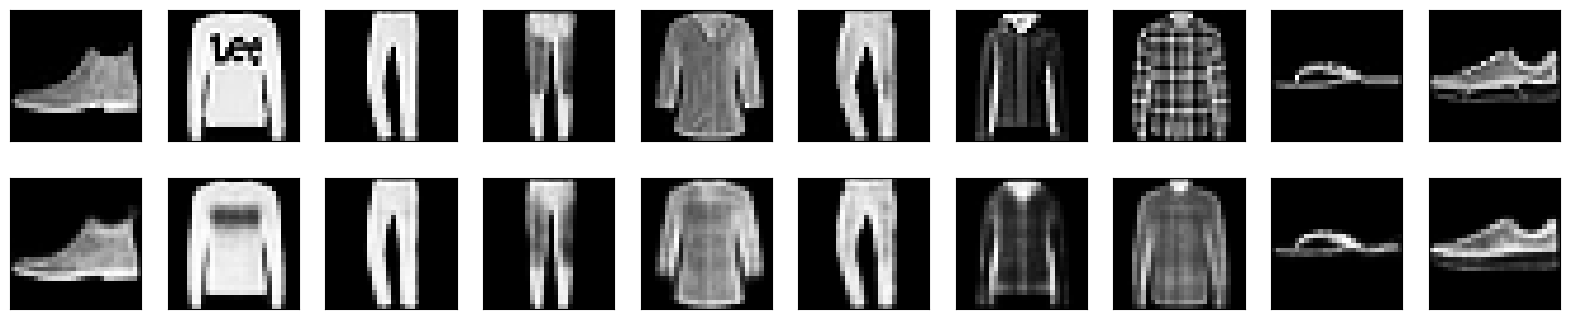

In [5]:
#model testi
#modeli encoder ve decoder olarak ikiye ayır
encoder = Model(input_image, encoded)

#decoder
encoded_input = Input(shape=(encoding_dim,))
decoder_layer1 = autoencoder.layers[-4](encoded_input)
decoder_layer2 = autoencoder.layers[-3](decoder_layer1)
decoder_layer3 = autoencoder.layers[-2](decoder_layer2)
decoder_output = autoencoder.layers[-1](decoder_layer3)

decoder = Model(encoded_input, decoder_output)

#test verisi ile encoder ve decoder ile sıkıştırma ve yeniden yapılandırma işlemi
encoded_images = encoder.predict(x_test) #latent temsili elde ederiz
decoded_images = decoder.predict(encoded_images) # latent temsillerini orijinal forma geri çevirir

#orijinal ve yeniden yapılandfırılmış (decoded_images) görüntüleri görselleştir
n = 10
plt.figure(figsize=(20,4))
for i in range(n):
    #orijinal görüntüler 
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray") #orijinal görüntü boyutuna çeviriyoruz
    ax.get_xaxis().set_visible(False) # x eksenini gizleme 
    ax.get_yaxis().set_visible(False)
    
    #decoded edilmiş yani yeniden yapılandırılmış görüntü
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_images[i].reshape(28,28), cmap="gray")
    ax.get_xaxis().set_visible(False) 
    ax.get_yaxis().set_visible(False)
plt.show()

In [6]:
#ssim skorlarnı hesaplama
def compute_ssim(orijinal, reconstructed):
    #her iki görüntü arasındaki ssim skorunu (0-1) hesapla
    orijinal = orijinal.reshape(28,28)
    reconstructed = reconstructed.reshape(28,28)
    return ssim(orijinal, reconstructed, data_range=1)

#test veri seti için ssim hesapla
ssim_score = []

#ilk 100 tanesini hesapla
for i in range(100):
    orijinal_image = x_test[i]
    reconstructed_img = decoded_images[i]
    score = compute_ssim(orijinal_image, reconstructed_img)
    ssim_score.append(score)
    
average_ssim = np.mean(ssim_score)
print("SSIM : ", average_ssim)

SSIM :  0.8344857303792638
